In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('..')  # so we can import from models/
from models.implied_vol import bsm_implied_vol, compute_smile
from models.bsm import bsm_price
from models.spx_chain import fetch_chain, fetch_chain_cached, clean_chain

In [2]:
# Generate a known price
sigma_true = 0.25
C = bsm_price(100, 100, 1.0, 0.05, sigma_true, 'call')

# Invert
sigma_implied = bsm_implied_vol(C, 100, 100, 1.0, 0.05, 'call')

print(f"True sigma:     {sigma_true}")
print(f"Implied sigma:  {sigma_implied}")
print(f"Difference:     {abs(sigma_true - sigma_implied):.2e}")

True sigma:     0.25
Implied sigma:  0.24999999999982547
Difference:     1.75e-13


In [3]:
# OTM call
sigma_true = 0.25
C = bsm_price(100, 110, 1.0, 0.05, sigma_true, 'call')
sigma_imp = bsm_implied_vol(C, 100, 110, 1.0, 0.05, 'call')
print(f"OTM call: true={sigma_true}, implied={sigma_imp}, diff={abs(sigma_true - sigma_imp):.2e}")

# OTM put
P = bsm_price(100, 90, 1.0, 0.05, sigma_true, 'put')
sigma_imp = bsm_implied_vol(P, 100, 90, 1.0, 0.05, 'put')
print(f"OTM put:  true={sigma_true}, implied={sigma_imp}, diff={abs(sigma_true - sigma_imp):.2e}")

OTM call: true=0.25, implied=0.24999999999998523, diff=1.48e-14
OTM put:  true=0.25, implied=0.24999999870277942, diff=1.30e-09


In [4]:
# A clearly invalid call price (below intrinsic)
result = bsm_implied_vol(0.01, 100, 100, 1.0, 0.05, 'call')
print(f"Below intrinsic: {result}")  # Should print 'nan'

# A clearly invalid call price (above S)
result = bsm_implied_vol(150, 100, 100, 1.0, 0.05, 'call')
print(f"Above upper bound: {result}")  # Should print 'nan'

Below intrinsic: nan
Above upper bound: nan


In [5]:
calls, puts = fetch_chain_cached('^SPX', '2026-07-16')
print(f"Calls: {calls.shape}, Puts: {puts.shape}")
print(f"\nColumns: {calls.columns.tolist()}")
print(f"\nFirst 5 calls:")
print(calls.head())
print(f"\nLast 5 calls:")
print(calls.tail())

Loading from cache: D:\GitHub\quant-project\notebooks\..\data\raw
Calls: (46, 14), Puts: (67, 14)

Columns: ['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']

First 5 calls:
        contractSymbol              lastTradeDate  strike  lastPrice    bid  \
0  SPXW260716C06700000  2026-06-15 19:50:50+00:00  6700.0     883.29  883.2   
1  SPXW260716C07000000  2026-06-11 19:27:02+00:00  7000.0     459.93  591.2   
2  SPXW260716C07100000  2026-06-12 15:22:59+00:00  7100.0     417.58  497.1   
3  SPXW260716C07125000  2026-06-03 14:38:33+00:00  7125.0     525.17  473.9   
4  SPXW260716C07150000  2026-06-03 14:38:33+00:00  7150.0     502.57  451.0   

     ask  change  percentChange  volume  openInterest  impliedVolatility  \
0  889.8     0.0            0.0     1.0             0           0.331889   
1  597.9     0.0            0.0     NaN             0       

In [6]:
print("Volume statistics for calls:")
print(calls['volume'].describe())
print(f"\nNumber of calls with volume = 0 or NaN: {(calls['volume'].fillna(0) == 0).sum()} / {len(calls)}")
print(f"Number of calls with volume >= 10: {(calls['volume'] >= 10).sum()} / {len(calls)}")
print(f"\nBid/Ask spread analysis (calls):")
spread_pct = (calls['ask'] - calls['bid']) / ((calls['ask'] + calls['bid']) / 2)
print(spread_pct.describe())

Volume statistics for calls:
count     36.000000
mean      40.444444
std      117.152024
min        1.000000
25%        2.000000
50%        6.000000
75%       17.500000
max      513.000000
Name: volume, dtype: float64

Number of calls with volume = 0 or NaN: 10 / 46
Number of calls with volume >= 10: 15 / 46

Bid/Ask spread analysis (calls):
count    46.000000
mean      0.048488
std       0.095573
min       0.003194
25%       0.008079
50%       0.015867
75%       0.021677
max       0.400000
dtype: float64


In [7]:
print(f"\nStrike range: {calls['strike'].min()} to {calls['strike'].max()}")
print(f"Spot: 7554.29")
print(f"\nNumber of strikes: {len(calls)}")


Strike range: 6700.0 to 8800.0
Spot: 7554.29

Number of strikes: 46


In [8]:
calls_clean = clean_chain(
    calls,
    min_volume=5,
    min_open_interest=0,
    max_relative_spread=0.5,
    max_staleness_days=7,
    verbose=True,
)
print(f"\nFinal: {len(calls_clean)} rows")
print(calls_clean[['strike', 'bid', 'ask', 'mid', 'volume', 'lastTradeDate']].sort_values('strike'))

Started: 46 rows
After bid > 0:               46
After spread filter:         46
After volume filter:         21
After open interest filter:  21
After staleness filter:      21

Final: 21 rows
    strike     bid     ask      mid  volume             lastTradeDate
9   7300.0  317.90  323.60  320.750     7.0 2026-06-11 19:41:29+00:00
11  7350.0  277.00  282.10  279.550    11.0 2026-06-12 15:19:28+00:00
17  7425.0  218.80  219.50  219.150     6.0 2026-06-09 13:55:27+00:00
21  7475.0  181.50  182.30  181.900    88.0 2026-06-15 20:11:32+00:00
22  7500.0  164.00  164.80  164.400   513.0 2026-06-15 19:26:38+00:00
23  7525.0  147.10  147.90  147.500   508.0 2026-06-15 19:25:52+00:00
24  7550.0  131.30  132.10  131.700    12.0 2026-06-15 19:35:52+00:00
25  7575.0  116.20  117.10  116.650    12.0 2026-06-15 19:26:35+00:00
26  7600.0  102.30  103.10  102.700    17.0 2026-06-15 19:54:55+00:00
27  7625.0   89.00   89.80   89.400    19.0 2026-06-15 19:54:55+00:00
28  7650.0   77.00   77.80   77.400  

In [9]:
# Run it
smile = compute_smile(
    calls_clean,
    spot=7554.29,
    T=30/365,
    r=0.045,
    option_type='call',
)
print(smile[['strike', 'mid', 'iv']].to_string())

    strike      mid        iv
9   7300.0  320.750  0.160930
11  7350.0  279.550  0.156384
17  7425.0  219.150  0.146849
21  7475.0  181.900  0.141080
22  7500.0  164.400  0.138425
23  7525.0  147.500  0.135649
24  7550.0  131.700  0.133280
25  7575.0  116.650  0.130839
26  7600.0  102.700  0.128679
27  7625.0   89.400  0.126230
28  7650.0   77.400  0.124209
30  7700.0   56.600  0.120581
31  7725.0   47.850  0.119053
33  7775.0   33.450  0.116539
37  7875.0   15.050  0.113344
38  7900.0   12.200  0.113022
39  8000.0    5.300  0.113787
40  8100.0    2.525  0.117849
42  8300.0    1.000  0.134916
43  8400.0    0.775  0.145772
44  8600.0    0.500  0.166612


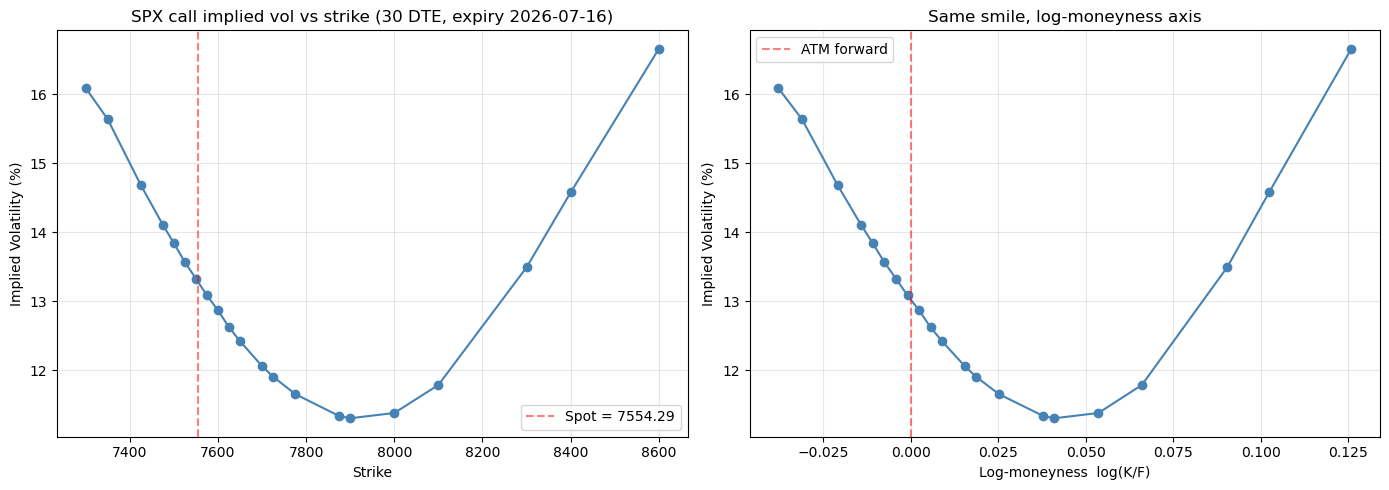

In [10]:
# Compute log-moneyness for the x-axis: log(K/F) where F = S * exp(rT)
spot = 7554.29
r = 0.045
T = 30/365
F = spot * np.exp(r * T)

smile['log_moneyness'] = np.log(smile['strike'] / F)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: IV vs strike
axes[0].plot(smile['strike'], smile['iv'] * 100, 'o-', color='steelblue')
axes[0].axvline(spot, color='red', linestyle='--', alpha=0.5, label=f'Spot = {spot}')
axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Implied Volatility (%)')
axes[0].set_title('SPX call implied vol vs strike (30 DTE, expiry 2026-07-16)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: IV vs log-moneyness - the conventional academic plot
axes[1].plot(smile['log_moneyness'], smile['iv'] * 100, 'o-', color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5, label='ATM forward')
axes[1].set_xlabel('Log-moneyness  log(K/F)')
axes[1].set_ylabel('Implied Volatility (%)')
axes[1].set_title('Same smile, log-moneyness axis')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()